In this homework, we’ll work with categorical variables, build our first machine learning models (Decision Trees), and perform hyperparameter tuning.

💡 Your goal is to read through the provided code and make slight extensions. Specifically:
- Add more columns to the dataframe.
- Define new “handcrafted” rules to predict growth.
- Analyze whether the ML model produces **unique** predictions (i.e., cases where only the ML model is correct compared to other “hand” rules).
- Tune the Decision Tree by optimizing its complexity (i.e., the **depth** hyperparameter).


Please use the [Colab Module 3](https://github.com/DataTalksClub/stock-markets-analytics-zoomcamp/blob/main/03-modeling/%5B2025%5D_Module_3_Colab_Time_Series_Modeling.ipynb) for all tasks to ensure you have the same dataframe used for the Modeling part, as covered during the lecture.

**HINT**: If you want to avoid data truncation in GitHub's UI, try either of the following options:
* Open the notebook in [Colab, using the GitHub link to the notebook](https://colab.research.google.com/github/DataTalksClub/stock-markets-analytics-zoomcamp/blob/main/03-modeling/%5B2025%5D_Module_3_Colab_Time_Series_Modeling.ipynb).
* Clone the repository to a local folder and open the notebook in Jupyter Notebook.
---
### Question 1: Dummies for Month and Week-of-Month

**What is the ABSOLUTE CORRELATION VALUE of the most correlated dummy variable <month>_w<week_of_month> with the binary outcome `is_positive_growth_30d_future`?**

From the correlation analysis and modeling, you may have observed that October and November are potentially important seasonal months. In this task, you'll go further by generating dummy variables for both the **Month** and **Week-of-Month** (starting from 1). For example, the first week of October should be coded as: `'October_w1'`.

Once you've generated these new variables, identify the one with the **highest absolute correlation** with `is_positive_growth_30d_future`, and round the result to **three decimal places**.


#### Suggested Steps

1. Use [this StackOverflow reference](https://stackoverflow.com/questions/25249033/week-of-a-month-pandas) to compute the week of the month using the following formula:
  ```python
  (d.day - 1) // 7 + 1
  ```
2. Create a new string variable that combines the month name and week of the month.
Example: 'October_w1', 'November_w2', etc.

3. Add the new variable (e.g., `month_wom`) to your set of **categorical features**.

   Your updated categorical feature list should include:
   - `'Month'`
   - `'Weekday'`
   - `'Ticker'`
   - `'ticker_type'`
   - `'month_wom'`

4. Use [`pandas.get_dummies()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html) to generate dummy variables for all categorical features.

   This should result in approximately **115 dummy variables**, including around **60** for the `month_wom` feature (`12 months × up to 5 weeks`).

5. Use [`DataFrame.corr()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) to compute the correlation between each feature and the target variable `is_positive_growth_30d_future`.

6. Filter the correlation results to include only the dummy variables generated from `month_wom`.

7. Create a new column named `abs_corr` in the correlation results that stores the **absolute value** of the correlations.

8. Sort the correlation results by `abs_corr` in **descending** order.

9. Identify and report the **highest absolute correlation value** among the `month_wom` dummy variables, rounded to **three decimal places**.


**NOTE**: new dummies will be used as features in the next tasks, please leave them in the dataset.

---

In [96]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.graph_objects as go
import plotly.express as px

import time
from datetime import date

# for graphs
import matplotlib.pyplot as plt

In [97]:
#1.Importing data from Drive & defining variable sets
!gdown https://drive.google.com/file/d/1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB/view?usp=sharing --fuzzy -O /content/

Downloading...
From (original): https://drive.google.com/uc?id=1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB
From (redirected): https://drive.google.com/uc?id=1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB&confirm=t&uuid=810b38c1-db40-4a8b-a78f-8329811ee9d0
To: /content/stocks_df_combined_2025_06_13.parquet.brotli
100% 130M/130M [00:02<00:00, 48.4MB/s]


In [98]:
df_full = pd.read_parquet("/content/stocks_df_combined_2025_06_13.parquet.brotli", )

In [99]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 230262 entries, 0 to 5700
Columns: 203 entries, Open to growth_btc_usd_365d
dtypes: datetime64[ns](3), float64(129), int32(64), int64(5), object(2)
memory usage: 302.2+ MB


In [100]:
df_full.keys()

Index(['Open', 'High', 'Low', 'Close_x', 'Volume', 'Dividends', 'Stock Splits',
       'Ticker', 'Year', 'Month',
       ...
       'growth_brent_oil_7d', 'growth_brent_oil_30d', 'growth_brent_oil_90d',
       'growth_brent_oil_365d', 'growth_btc_usd_1d', 'growth_btc_usd_3d',
       'growth_btc_usd_7d', 'growth_btc_usd_30d', 'growth_btc_usd_90d',
       'growth_btc_usd_365d'],
      dtype='object', length=203)

In [101]:
df_full.head(3)

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,growth_brent_oil_7d,growth_brent_oil_30d,growth_brent_oil_90d,growth_brent_oil_365d,growth_btc_usd_1d,growth_btc_usd_3d,growth_btc_usd_7d,growth_btc_usd_30d,growth_btc_usd_90d,growth_btc_usd_365d
0,0.054277,0.062259,0.054277,0.059598,1.031789e+09,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.059598,0.062791,0.059598,0.061726,3.081600e+08,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.061726,0.063323,0.061726,0.062791,1.331712e+08,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
print(df_full.shape)

(230262, 203)


In [103]:
#2.Create a new string variable that combines the month name and week of the month. Example: 'October_w1', 'November_w2', etc.
# dummy variables are not generated from Date and numeric variables
df_full.loc[:,'Month'] = df_full.Month.dt.strftime('%B')
df_full.loc[:,'Weekday'] = df_full.Weekday.astype(str)
df_full['week_of_month'] = df_full['Date'].apply(lambda d: (d.day-1) // 7 + 1).astype(str)

/tmp/ipython-input-103-1630588251.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['March' 'March' 'March' ... 'June' 'June' 'June']' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df_full.loc[:,'Month'] = df_full.Month.dt.strftime('%B')
/tmp/ipython-input-103-1630588251.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['3' '4' '0' ... '2' '3' '4']' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df_full.loc[:,'Weekday'] = df_full.Weekday.astype(str)


In [104]:
#3.Add the new variable (e.g., month_wom) to your set of categorical features.
df_full['month_wom'] = df_full['Month']+'_w'+df_full['week_of_month']
df_full['month_wom'].head()

,month_wom
0,March_w2
1,March_w2
2,March_w3
3,March_w3
4,March_w3


In [105]:
#4.Define features
GROWTH = [g for g in df_full.keys() if (g.find('growth_')==0)&(g.find('future')<0)]
OHLCV = ['Open','High','Low','Close','Adj Close_x','Volume']
CATEGORICAL = ['Month', 'Weekday', 'Ticker', 'ticker_type', 'month_wom']
TO_PREDICT = [g for g in df_full.keys() if (g.find('future')>=0)]
TO_DROP = ['Year','Date','index_x', 'index_y', 'index', 'Quarter','Adj Close_y'] + CATEGORICAL + OHLCV
TARGET = 'is_positive_growth_30d_future'

In [106]:
# let's define on more custom numerical features
df_full['ln_volume'] = df_full.Volume.apply(lambda x: np.log(x))

/tmp/ipython-input-106-2841410488.py:2: RuntimeWarning: divide by zero encountered in log
  df_full['ln_volume'] = df_full.Volume.apply(lambda x: np.log(x))


In [107]:
# manually defined features
CUSTOM_NUMERICAL = ['SMA10', 'SMA20', 'growing_moving_average', 'high_minus_low_relative','volatility', 'ln_volume']

In [108]:
# All Supported Ta-lib indicators: https://github.com/TA-Lib/ta-lib-python/blob/master/docs/funcs.md

TECHNICAL_INDICATORS = ['adx', 'adxr', 'apo', 'aroon_1','aroon_2', 'aroonosc',
 'bop', 'cci', 'cmo','dx', 'macd', 'macdsignal', 'macdhist', 'macd_ext',
 'macdsignal_ext', 'macdhist_ext', 'macd_fix', 'macdsignal_fix',
 'macdhist_fix', 'mfi', 'minus_di', 'mom', 'plus_di', 'dm', 'ppo',
 'roc', 'rocp', 'rocr', 'rocr100', 'rsi', 'slowk', 'slowd', 'fastk',
 'fastd', 'fastk_rsi', 'fastd_rsi', 'trix', 'ultosc', 'willr',
 'ad', 'adosc', 'obv', 'atr', 'natr', 'ht_dcperiod', 'ht_dcphase',
 'ht_phasor_inphase', 'ht_phasor_quadrature', 'ht_sine_sine', 'ht_sine_leadsine',
 'ht_trendmod', 'avgprice', 'medprice', 'typprice', 'wclprice']

In [109]:
TECHNICAL_PATTERNS = [g for g in df_full.keys() if g.find('cdl')>=0]
print(f'Technical patterns count = {len(TECHNICAL_PATTERNS)}, examples = {TECHNICAL_PATTERNS[0:5]}')

Technical patterns count = 61, examples = ['cdl2crows', 'cdl3blackrows', 'cdl3inside', 'cdl3linestrike', 'cdl3outside']


In [110]:
MACRO = ['gdppot_us_yoy', 'gdppot_us_qoq', 'cpi_core_yoy', 'cpi_core_mom', 'FEDFUNDS',
 'DGS1', 'DGS5', 'DGS10']

In [111]:
NUMERICAL = GROWTH + TECHNICAL_INDICATORS + TECHNICAL_PATTERNS + CUSTOM_NUMERICAL + MACRO

In [112]:
# CHECK: NO OTHER INDICATORS LEFT
OTHER = [k for k in df_full.keys() if k not in OHLCV + CATEGORICAL + NUMERICAL + TO_DROP]
OTHER

['Close_x',
 'Dividends',
 'Stock Splits',
 'growth_future_30d',
 'is_positive_growth_30d_future',
 'Close_y',
 'week_of_month']

In [113]:
# truncated df_full with 25 years of data (and defined growth variables)
df = df_full[df_full.Date>='2000-01-01']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 206 entries, Open to ln_volume
dtypes: datetime64[ns](2), float64(130), int32(63), int64(5), object(6)
memory usage: 256.8+ MB


In [114]:
#4.Use pandas.get_dummies() to generate dummy variables for all categorical features.
dummy_variables = pd.get_dummies(df[CATEGORICAL], dtype='int32')
print(dummy_variables.shape)
dummy_variables.head()

(191795, 115)


,Month_April,Month_August,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,...,month_wom_October_w1,month_wom_October_w2,month_wom_October_w3,month_wom_October_w4,month_wom_October_w5,month_wom_September_w1,month_wom_September_w2,month_wom_September_w3,month_wom_September_w4,month_wom_September_w5
3490,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3491,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3492,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3493,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3494,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [115]:
dummy_variables.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 115 entries, Month_April to month_wom_September_w5
dtypes: int32(115)
memory usage: 85.6 MB


In [116]:
#get dummies names in a list
DUMMIES = dummy_variables.keys().to_list()

In [117]:
# Concatenate the dummy variables with the original DataFrame
df_with_dummies = pd.concat([df, dummy_variables], axis=1)
print(df_with_dummies.shape)
df_with_dummies.info()

(191795, 321)
<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 321 entries, Open to month_wom_September_w5
dtypes: datetime64[ns](2), float64(130), int32(178), int64(5), object(6)
memory usage: 340.9+ MB


In [118]:
#5.Use DataFrame.corr() to compute the correlation between each feature and the target variable is_positive_growth_30d_future.
corr_is_positive_growth_30d_future = df_with_dummies[NUMERICAL+DUMMIES+TO_PREDICT].corr()['is_positive_growth_30d_future']

In [119]:
# Filter the correlation results to include only the dummy variables generated from month_wom.
filter_df_corr_is_positive_growth_30d_future = pd.DataFrame(corr_is_positive_growth_30d_future[corr_is_positive_growth_30d_future.index.str.startswith('month_wom')])
filter_df_corr_is_positive_growth_30d_future.head()

,is_positive_growth_30d_future
month_wom_April_w1,-0.001600
month_wom_April_w2,-0.002640
month_wom_April_w3,0.006208
month_wom_April_w4,0.004110
month_wom_April_w5,0.001731


In [120]:
# Create a new column named abs_corr in the correlation results that stores the absolute value of the correlations.
filter_df_corr_is_positive_growth_30d_future['abs_corr'] = filter_df_corr_is_positive_growth_30d_future['is_positive_growth_30d_future'].abs()
filter_df_corr_is_positive_growth_30d_future.head(5)

,is_positive_growth_30d_future,abs_corr
month_wom_April_w1,-0.001600,0.001600
month_wom_April_w2,-0.002640,0.002640
month_wom_April_w3,0.006208,0.006208
month_wom_April_w4,0.004110,0.004110
month_wom_April_w5,0.001731,0.001731


In [121]:
# Sort the correlation results by abs_corr in descending order.
filter_df_corr_is_positive_growth_30d_future.sort_values(by='abs_corr', ascending=False, inplace=True)
filter_df_corr_is_positive_growth_30d_future.head(5)

,is_positive_growth_30d_future,abs_corr
month_wom_October_w4,0.024968,0.024968
month_wom_November_w3,0.022097,0.022097
month_wom_November_w2,0.018822,0.018822
month_wom_January_w2,-0.018327,0.018327
month_wom_October_w3,0.017734,0.017734


In [122]:
# Identify and report the highest absolute correlation value among the month_wom dummy variables, rounded to three decimal places.
highest = filter_df_corr_is_positive_growth_30d_future.iloc[0]['abs_corr'].round(3)
mow = filter_df_corr_is_positive_growth_30d_future.index[0]
print(f'The highest absolute correlation value among the month_wom dummy variables is {highest} ({mow})')

The highest absolute correlation value among the month_wom dummy variables is 0.025 (month_wom_October_w4)


---
### Question 2:  Define New "Hand" Rules on Macro and Technical Indicator Variables

**What is the precision score for the best of the NEW predictions (`pred3` or `pred4`), rounded to 3 digits after the comma?**

In this task, you'll apply insights from the **visualized decision tree (`clf10`)** (see *Code Snippet 5: 1.4.4 Visualisation*) to manually define and evaluate new predictive rules.


1. **Define two new 'hand' rules** based on branches that lead to 'positive' predictions in the tree:
   - `pred3_manual_dgs10_5`:  
     ```python
     (DGS10 <= 4) & (DGS5 <= 1)
     ```
   - `pred4_manual_dgs10_fedfunds`:  
     ```python
     (DGS10 > 4) & (FEDFUNDS <= 4.795)
     ```
   > **Hint**: This is not exactly the same condition as in the estimated tree (original: `(DGS10 <= 4.825) & (DGS5 <= 0.745)`; `(DGS10 > 4.825) & (FEDFUNDS <= 4.795)`), since in that case, there are no true positive predictions for both variables. Consider why this might be the case.


2. **Extend Code Snippet 3** (Manual "hand rule" predictions):  
   - Implement and apply the above two rules (`pred3`, `pred4`) to your dataset.
   - Add the resulting predictions as new columns in your dataframe (e.g., `new_df`).

3. **Compute precision**:
   - For the rule that **does** make positive predictions on the TEST set, compute its **precision score**.
   - Use standard precision metrics (`TP / (TP + FP)`).
   - Round the precision score to **three decimal places**.  
     Example: If your result is `0.57897`, your final answer should be: `0.579`.
  > **Hint**: This should already be visible in the code output, as the `IS_CORRECT` and `PREDICTIONS` sets should automatically include the new columns.



---

In [123]:
# temporal split
def temporal_split(df, min_date, max_date, train_prop=0.7, val_prop=0.15, test_prop=0.15):
    """
    Splits a DataFrame into three buckets based on the temporal order of the 'Date' column.

    Args:
        df (DataFrame): The DataFrame to split.
        min_date (str or Timestamp): Minimum date in the DataFrame.
        max_date (str or Timestamp): Maximum date in the DataFrame.
        train_prop (float): Proportion of data for training set (default: 0.6).
        val_prop (float): Proportion of data for validation set (default: 0.2).
        test_prop (float): Proportion of data for test set (default: 0.2).

    Returns:
        DataFrame: The input DataFrame with a new column 'split' indicating the split for each row.
    """
    # Define the date intervals
    train_end = min_date + pd.Timedelta(days=(max_date - min_date).days * train_prop)
    val_end = train_end + pd.Timedelta(days=(max_date - min_date).days * val_prop)

    # Assign split labels based on date ranges
    split_labels = []
    for date in df['Date']:
        if date <= train_end:
            split_labels.append('train')
        elif date <= val_end:
            split_labels.append('validation')
        else:
            split_labels.append('test')

    # Add 'split' column to the DataFrame
    df['split'] = split_labels

    return df

In [124]:
min_date_df = df_with_dummies.Date.min()
max_date_df = df_with_dummies.Date.max()
print(min_date_df, max_date_df)
df_with_dummies = temporal_split(df_with_dummies,
                                 min_date = min_date_df,
                                 max_date = max_date_df)

2000-01-03 00:00:00 2025-06-13 00:00:00


In [126]:
df_with_dummies['split'].value_counts()/len(df_with_dummies)

,count
split,
train,0.676399
test,0.163758
validation,0.159843


In [127]:
# remove the "segmentation" problem (warning message on df performance after many joins and data transformations)
new_df = df_with_dummies.copy()

In [128]:
# generate manual predictions
# Let's label all prediction features with prefix "pred"
new_df['pred0_manual_cci'] = (new_df.cci>200).astype(int)
new_df['pred1_manual_prev_g1'] = (new_df.growth_30d>1).astype(int)
new_df['pred2_manual_prev_g1_and_snp'] = ((new_df['growth_30d'] > 1) & (new_df['growth_snp500_30d'] > 1)).astype(int)

In [130]:
# Define two new 'hand' rules based on branches that lead to 'positive' predictions in the tree
new_df['pred3_manual_dgs10_5'] = ((new_df['DGS10'] <= 4) & (new_df['DGS5'] <= 1)).astype(int)
new_df['pred4_manual_dgs10_fedfunds'] = ((new_df['DGS10'] > 4) & (new_df['FEDFUNDS'] <= 4.795)).astype(int)
new_df[['pred3_manual_dgs10_5','pred4_manual_dgs10_fedfunds']].sample(5)

,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds
7645,0,0
5720,0,0
1012,0,0
8581,0,0
6140,1,0


In [131]:
# Implement and apply the above two rules (pred3, pred4) to your dataset.
PREDICTIONS = [k for k in new_df.keys() if k.startswith('pred')]
PREDICTIONS

['pred0_manual_cci',
 'pred1_manual_prev_g1',
 'pred2_manual_prev_g1_and_snp',
 'pred3_manual_dgs10_5',
 'pred4_manual_dgs10_fedfunds']

In [133]:
# Add the resulting predictions as new columns in your dataframe
# generate columns is_correct_
for pred in PREDICTIONS:
  part1 = pred.split('_')[0] # first prefix before '_'
  new_df[f'is_correct_{part1}'] =  (new_df[pred] == new_df.is_positive_growth_30d_future).astype(int)

In [134]:
# IS_CORRECT dataset
IS_CORRECT =  [k for k in new_df.keys() if k.startswith('is_correct_')]
IS_CORRECT

['is_correct_pred0',
 'is_correct_pred1',
 'is_correct_pred2',
 'is_correct_pred3',
 'is_correct_pred4']

In [135]:
# sample of a dataframe
new_df[PREDICTIONS+IS_CORRECT+['is_positive_growth_30d_future']].sample(5)

,pred0_manual_cci,pred1_manual_prev_g1,pred2_manual_prev_g1_and_snp,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds,is_correct_pred0,is_correct_pred1,is_correct_pred2,is_correct_pred3,is_correct_pred4,is_positive_growth_30d_future
4290,0,1,1,0,0,0,1,1,0,0,1
4144,0,1,0,0,0,0,1,0,0,0,1
12307,0,0,0,1,0,0,0,0,1,0,1
5022,0,1,1,1,0,0,1,1,1,0,1
4764,0,1,1,1,0,0,1,1,1,0,1


In [136]:
len(new_df[new_df.split=='test'])

31408

In [144]:
# Compute precision
# define "Precision" for ALL predictions on a Test dataset (~4 last years of trading)
for i,column in enumerate(IS_CORRECT):
  prediction_column = PREDICTIONS[i]
  is_correct_column = column
  filter = (new_df.split=='test') & (new_df[prediction_column]==1)
  print(f'Prediction column:{prediction_column} , is_correct_column: {is_correct_column}')
  print(new_df[filter][is_correct_column].value_counts())
  print(new_df[filter][is_correct_column].value_counts()/len(new_df[filter]))
  print('---------')

Prediction column:pred0_manual_cci , is_correct_column: is_correct_pred0
is_correct_pred0
1    443
0    351
Name: count, dtype: int64
is_correct_pred0
1    0.557935
0    0.442065
Name: count, dtype: float64
---------
Prediction column:pred1_manual_prev_g1 , is_correct_column: is_correct_pred1
is_correct_pred1
1    9748
0    8243
Name: count, dtype: int64
is_correct_pred1
1    0.541826
0    0.458174
Name: count, dtype: float64
---------
Prediction column:pred2_manual_prev_g1_and_snp , is_correct_column: is_correct_pred2
is_correct_pred2
1    6984
0    6383
Name: count, dtype: int64
is_correct_pred2
1    0.522481
0    0.477519
Name: count, dtype: float64
---------
Prediction column:pred3_manual_dgs10_5 , is_correct_column: is_correct_pred3
is_correct_pred3
1    578
0    419
Name: count, dtype: int64
is_correct_pred3
1    0.579739
0    0.420261
Name: count, dtype: float64
---------
Prediction column:pred4_manual_dgs10_fedfunds , is_correct_column: is_correct_pred4
is_correct_pred4
0    30

Whatis the precision score for the best of the NEW predictions (pred3 or pred4), rounded to 3 digits after the comma?

Ans: 0.580  Prediction column:pred3_manual_dgs10_5

---
### Question 3: Unique Correct Predictions from a 10-Level Decision Tree Classifier (`pred5_clf_10`)

**What is the total number of records in the TEST dataset where the new prediction `pred5_clf_10` is correct, while all 'hand' rule predictions (`pred0` to `pred4`) are incorrect?**


To ensure reproducibility, please include the following parameter in the Decision Tree Classifier:
```python
clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
```


#### Step 1: Train the Decision Tree and Generate Predictions

- Initialize a Decision Tree Classifier with a maximum depth of 10 and set `random_state=42` for reproducibility.
- Fit the classifier on the combined TRAIN and VALIDATION datasets.
- Use the trained model to predict on the entire dataset (TRAIN + VALIDATION + TEST).
- Store these predictions in a new column named `pred5_clf_10` within your main dataframe.
- **Hint**: When predicting on the entire dataset, it's easy to join the predictions with the full DataFrame, since the number of records and their order remain the same. You will need to define X_all and y_all and apply the same cleaning steps used previously for X_train, y_train, X_test, and y_test. This makes it straightforward to define a new column, for example:  
  ```python
  df['pred5_clf_10'] = <predictions vector from clf10.predict(X_all)>

#### Step 2: Identify Unique Correct Predictions by `pred5_clf_10`

- Create a new boolean column, `only_pred5_is_correct`, that is `True` only when:
  - The prediction from `pred5_clf_10` is correct (i.e., matches the true label).
  - All other hand rule predictions (`pred0` through `pred4`) are incorrect.

#### Step 3: Count Unique Correct Predictions on the TEST Set

- Convert the `only_pred5_is_correct` column from boolean to integer.
- Filter the dataframe for records belonging to the TEST dataset.
- Count how many records in the TEST set have `only_pred5_is_correct` equal to 1.
- Report this count as your final answer.

### Advanced (Optional)

- To generalize this for many prediction columns (e.g., `pred0` to `pred99`), define a function that can be applied to an entire dataframe row.
- This function should identify whether a specific prediction (`predX`) is uniquely correct (correct while all others are incorrect).
- This approach avoids hardcoding conditions for each predictor and scales easily.
- For examples of how to apply functions to rows in pandas, see this helpful resource:  
  [Pandas apply function to every row](https://sparkbyexamples.com/pandas/pandas-apply-function-to-every-row/)

---

In [146]:
# Split the data into train, validation, test sets based on the split date
features_list = NUMERICAL+DUMMIES
train_df = new_df[new_df['split'].isin(['train','validation'])]
test_df = new_df[new_df['split'].isin(['test'])]
val_df = new_df[new_df['split'].isin(['validation'])]
train_df.shape, test_df.shape, val_df.shape

((160387, 332), (31408, 332), (30657, 332))

In [187]:
def get_X_y(df, suffix=''):
    X = df[features_list+[TARGET,'Date','Ticker']].copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Need to fill NaNs somehow
    X.fillna(0, inplace=True)
    y = X.pop(TARGET).values
    print(f'length: X_{suffix} {X.shape}, y_{suffix} {len(y)}')
    return X, y

X_train, y_train = get_X_y(train_df, 'train')
X_test, y_test = get_X_y(test_df, 'test')
X_val, y_val = get_X_y(val_df, 'val')
X_full, y_full = get_X_y(new_df, 'full')

print(f'length: X_train {X_train.shape},  X_test {X_test.shape}, X_val {X_val.shape}, X_full {X_full.shape}')


length: X_train (160387, 301), y_train 160387
length: X_test (31408, 301), y_test 31408
length: X_val (30657, 301), y_val 30657
length: X_full (191795, 301), y_full 191795
length: X_train (160387, 301),  X_test (31408, 301), X_val (30657, 301), X_full (191795, 301)


In [188]:
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

In [189]:
# Initialize a Decision Tree Classifier with a maximum depth of 10 and set random_state=42 for reproducibility.
clf = DecisionTreeClassifier(max_depth=10, random_state=42)
# Fit the classifier on the combined TRAIN and VALIDATION datasets
clf.fit(X_train.drop(['Date','Ticker'],axis=1), y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [191]:
# Use the trained model to predict on the entire dataset (TRAIN + VALIDATION + TEST)
y_pred = clf.predict(X_full.drop(['Date','Ticker'],axis=1))

In [198]:
# Store these predictions in a new column named pred5_clf_10 within your main dataframe.
new_df['pred5_clf_10'] = y_pred

In [203]:
# Identify Unique Correct Predictions by pred5_clf_10
#IS_CORRECT
new_df['only_pred5_is_correct'] = (
    ((new_df['pred5_clf_10'] == new_df[TARGET]) &
     (new_df[IS_CORRECT].sum(axis=1) == 0))
).astype(int)

new_df.query("split == 'test'")['only_pred5_is_correct'].sum()

np.int64(3770)

---
### Question 4:  Hyperparameter tuning for a Decision Tree

**What is the optimal tree depth (from 1 to 20) for a DecisionTreeClassifier?**

**NOTE:** please include `random_state=42` to the Decision Tree Classifier initialization (e.g., `clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)`) to ensure consistency in results.

### Instructions:

- Iterate through `max_depth` values from 1 to 20.
- For each `max_depth`:
  - Train a Decision Tree Classifier with the current `max_depth` on the combined TRAIN+VALIDATION dataset.
- Optionally, visualize how the 'head' (top levels) of each fitted tree changes with increasing tree depth. You can use:
  - [`sklearn.tree.plot_tree()`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) for graphical visualization, or
  - The compact textual approach with `export_text()` function. For example:
    ```python
    from sklearn.tree import export_text
    tree_rules = export_text(model, feature_names=list(X_train), max_depth=3)
    print(tree_rules)
    ```
- Calculate the precision score on the TEST dataset for each fitted tree. You may also track precision on the VALIDATION dataset to observe signs of overfitting.
- Identify the optimal `max_depth` where the precision score on the TEST dataset is highest. This value is your **best_max_depth**.
- Using **best_max_depth**, retrain the Decision Tree Classifier on the combined TRAIN+VALIDATION set.
- Predict on the entire dataset (TRAIN + VALIDATION + TEST) and add the predictions as a new column `pred6_clf_best` in your dataframe `new_df`.
- Compare the precision score of the tuned tree with previous predictions (`pred0` to `pred5`). You should observe an improvement, ideally achieving precision > 0.58, indicating the tuned tree outperforms earlier models.

### Advanced (Optional)

- Plot the precision (or accuracy) scores against the `max_depth` values to detect saturation or overfitting trends.
- Observe the trade-off between model complexity (deeper trees) and generalization capability.
- For more information, consult the [scikit-learn Decision Trees documentation](https://scikit-learn.org/stable/modules/tree.html).

In [208]:
# Iterate through max_depth values from 1 to 20.
results = []
for max_depth in range(1, 21):
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)

    clf.fit(X_train.drop(['Date','Ticker'],axis=1), y_train)

    precission_test = precision_score(y_test, clf.predict(X_test.drop(['Date','Ticker'],axis=1)))
    precission_val = precision_score(y_val, clf.predict(X_val.drop(['Date','Ticker'],axis=1)))

    results.append([max_depth, precission_test, precission_val])

In [223]:
df_results = pd.DataFrame(results, columns=['max_depth','precission_test','precission_val'])
best_max_depth = df_results.sort_values(by='precission_test', ascending=False).iloc[0]
# best_max_depth
print(f"Best max_depth is {int(best_max_depth['max_depth'])}, with the highest precision score {best_max_depth['precission_test']:.3f}")

Best max_depth is 5, with the highest precision score 0.628


In [224]:
# Using best_max_depth, retrain the Decision Tree Classifier on the combined TRAIN+VALIDATION set.
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train.drop(['Date','Ticker'],axis=1), y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [225]:
# Predict on the entire dataset (TRAIN + VALIDATION + TEST) and add the predictions as a new column pred6_clf_best in your dataframe new_df
y_pred = clf.predict(X_full.drop(['Date','Ticker'],axis=1))
new_df['pred6_clf_best'] = y_pred

In [226]:
# Compare the precision score of the tuned tree with previous predictions (pred0 to pred5).
# You should observe an improvement, ideally achieving precision > 0.58, indicating the tuned tree outperforms earlier models.
PREDICTIONS = [k for k in new_df.keys() if k.startswith('pred')]
PREDICTIONS

['pred0_manual_cci',
 'pred1_manual_prev_g1',
 'pred2_manual_prev_g1_and_snp',
 'pred3_manual_dgs10_5',
 'pred4_manual_dgs10_fedfunds',
 'pred5_clf_10',
 'pred6_clf_best']

In [227]:
# generate columns is_correct_
for pred in PREDICTIONS:
  part1 = pred.split('_')[0] # first prefix before '_'
  new_df[f'is_correct_{part1}'] =  (new_df[pred] == new_df[TARGET]).astype(int)

In [228]:
# IS_CORRECT dataset
IS_CORRECT =  [k for k in new_df.keys() if k.startswith('is_correct_')]
IS_CORRECT

['is_correct_pred0',
 'is_correct_pred1',
 'is_correct_pred2',
 'is_correct_pred3',
 'is_correct_pred4',
 'is_correct_pred5',
 'is_correct_pred6']

In [230]:
for i,column in enumerate(IS_CORRECT):
    prediction_column = PREDICTIONS[i]
    is_correct_column = column
    filter = (new_df.split=='test') & (new_df[prediction_column]==1)
    p_score = precision_score(new_df[filter][TARGET], new_df[filter][prediction_column])
    print(f'precission score {p_score:.3f} for prediction column {prediction_column}')

precission score 0.558 for prediction column pred0_manual_cci
precission score 0.542 for prediction column pred1_manual_prev_g1
precission score 0.522 for prediction column pred2_manual_prev_g1_and_snp
precission score 0.580 for prediction column pred3_manual_dgs10_5
precission score 0.466 for prediction column pred4_manual_dgs10_fedfunds
precission score 0.589 for prediction column pred5_clf_10
precission score 0.628 for prediction column pred6_clf_best


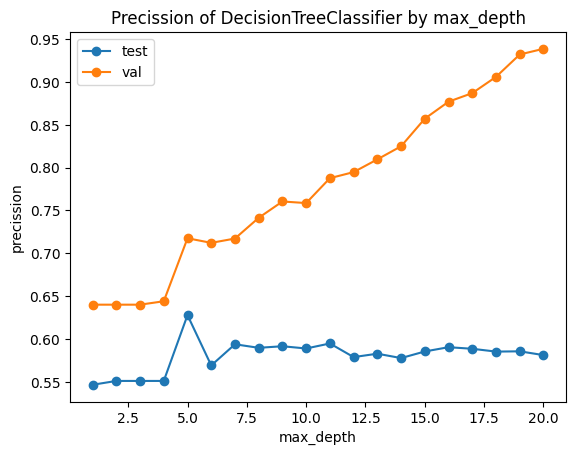

In [231]:
# Plot the precision (or accuracy) scores against the max_depth values to detect saturation or overfitting trends.
plt.plot(df_results['max_depth'], df_results['precission_test'], label='test', marker='o')
plt.plot(df_results['max_depth'], df_results['precission_val'], label='val', marker='o')
plt.title('Precission of DecisionTreeClassifier by max_depth')
plt.xlabel('max_depth')
plt.ylabel('precission')
plt.legend();